# WSH6 analytical database — reproducible 620-case generation

This notebook regenerates the WSH6-centered analytical database used in "An Analytical Database for Reinforced Concrete Structural Walls Based on an Experimentally Validated ML-Integrated Modeling Framework".

Workflow:
1. Read the 31 reinforcement configurations from `Configurations_model_input.xlsx`.
2. Run the WSH6 reference model and compare it with `WSH6_measured.csv`.
3. Generate one common 20-point LHS of concrete compressive strength (20–60 MPa) and axial load ratio (5–45%).
4. Cross the same 20 LHS points with all 31 configurations to obtain 620 analyses.
5. Run the nonlinear OpenSees analyses with checkpointing.
6. Extract response metrics and export the final analytical database.

Fixed WSH6 properties are stored in `wsh6_reference.py` (WSH6, Dazio et al., 2009). The FE models are:
- `run_FEmodel_webconf.py` for web-reinforcement configurations
- `run_FEmodel_boundconf.py` for boundary-reinforcement configurations

The original `Database_pydet.xlsx` workbook is not required.


In [2]:
# =============================================================================
# 1. Imports, paths, and analysis settings
# =============================================================================

from pathlib import Path
from contextlib import redirect_stdout, redirect_stderr
import os
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openseespy.opensees as op
import math

import wsh6_reference as ref
from run_FEmodel_webconf import run_wall_model
from run_FEmodel_boundconf import run_wall_model_BC



# Repository paths
repo_root = Path.cwd().resolve()

config_file = repo_root / "Configurations_model_input.xlsx"
measured_file = repo_root / "WSH6_measured.csv"
calibration_dir = repo_root / "PublicUse" / "MLmodel"

output_dir = repo_root / "outputs"
fe_runs_dir = output_dir / "FE_Runs"
reference_dir = output_dir / "WSH6_reference_validation"

design_file = output_dir / "WSH6_Final_620_Design.xlsx"
checkpoint_file = output_dir / "WSH6_Final_620_FE_Checkpoint.xlsx"
final_database_file = output_dir / "WSH6_Master_Database_620.xlsx"
validation_figure = output_dir / "WSH6_reference_validation.png"
section_plot_file = repo_root / "section_plot.py"

output_dir.mkdir(parents=True, exist_ok=True)


# Sampling settings
n_lhs = 20
lhs_seed = 120
fc_range_mpa = (20.0, 60.0)
alr_range_percent = (5.0, 45.0)

# True: delete old FE runs and rebuild all 620 analyses.
# False: resume from the checkpoint file if it exists.
rebuild_from_scratch = True


# WSH6 cyclic displacement protocol (m)
disps = [
     0.0094934, -0.0085847,
     0.0104020, -0.0098859,
     0.0257800, -0.0321520,
     0.0254130, -0.0263880,
     0.0377780, -0.0392380,
     0.0448240, -0.0396110,
     0.0512100, -0.0515270,
     0.0518330, -0.0509550,
     0.0646990, -0.0644790,
     0.0653210, -0.0638100,
     0.0776150, -0.0781410,
     0.0775790, -0.0777940,
     0.0947030, -0.0908150,
]


# Basic repository check
required_paths = [
    config_file,
    measured_file,
    calibration_dir,
    repo_root / "wsh6_reference.py",
    repo_root / "run_FEmodel_webconf.py",
    repo_root / "run_FEmodel_boundconf.py",
]

missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing repository input(s):\n" +
        "\n".join(f"- {path}" for path in missing)
    )


def read_response(case_dir):
    """Read TopDisp.out and RBase.out and return displacement (m) and force (kN)."""
    top_file = Path(case_dir) / "TopDisp.out"
    base_file = Path(case_dir) / "RBase.out"

    if not top_file.exists() or not base_file.exists():
        raise FileNotFoundError(f"Recorder files are missing in {case_dir}")

    disp = np.asarray(np.loadtxt(top_file), dtype=float).reshape(-1)
    base = np.atleast_2d(np.asarray(np.loadtxt(base_file), dtype=float))

    if len(disp) != len(base):
        raise ValueError("TopDisp.out and RBase.out have different lengths.")
    if base.shape[1] < 2:
        raise ValueError("RBase.out must contain at least two columns.")

    force = -base[:, 1] / 1000.0
    return disp, force


In [4]:
# =============================================================================
# 2. Read reinforcement configurations from Configurations_model_input.xlsx
# =============================================================================


def clean_configuration_sheet(df, required_columns):
    """Keep only rows that contain a complete reinforcement configuration."""
    if "Case" not in df.columns:
        raise KeyError("Each configuration sheet must contain a 'Case' column.")

    df = df.copy()
    df = df[df["Case"].notna()]
    df["Case"] = df["Case"].astype(str).str.strip()
    df = df.dropna(subset=required_columns)
    return df.reset_index(drop=True)


# Web configurations
web = pd.read_excel(config_file, sheet_name="Web variations")
web = clean_configuration_sheet(
    web,
    ["rho_bl", "rho_sh", "rho_t", "dbar", "webspacing"],
)

web = web.rename(columns={
    "Case": "Configuration",
    "dbar": "dbar_mm",
    "webspacing": "webspacing_mm",
})

# If rho_l is absent or blank, calculate the nominal spacing-based value.
bar_area = np.pi * (web["dbar_mm"] * 1e-3) ** 2 / 4.0
rho_l_from_spacing = (
    ref.web_face_count * bar_area
    / (web["webspacing_mm"] * 1e-3 * ref.wall_thickness)
    * 100.0
)

if "rho_l" not in web.columns:
    web["rho_l"] = rho_l_from_spacing
else:
    web["rho_l"] = pd.to_numeric(web["rho_l"], errors="coerce")
    web["rho_l"] = web["rho_l"].fillna(rho_l_from_spacing)

web["Configuration_family"] = np.where(
    web["Configuration"].eq("Base model"),
    "Reference",
    "Web",
)
web["dbar1_mm"] = np.nan
web["no_bars_bl"] = np.nan


# Boundary configurations
boundary = pd.read_excel(
    config_file,
    sheet_name="Boundary variations"
)

boundary = clean_configuration_sheet(
    boundary,
    ["rho_bl", "rho_sh", "rho_l", "rho_t", "dbar", "No bars"],
)

# Base model is already included in the Web variations sheet.
# Keep only the 12 boundary-variation cases here.
boundary = boundary[
    boundary["Case"] != "Base model"
].copy()

boundary = boundary.rename(columns={
    "Case": "Configuration",
    "dbar": "dbar1_mm",
    "No bars": "no_bars_bl",
})

boundary["Configuration_family"] = "Boundary"
boundary["dbar_mm"] = np.nan
boundary["webspacing_mm"] = np.nan


# Standardized configuration table
config_columns = [
    "Configuration", "Configuration_family",
    "rho_bl", "rho_sh", "rho_l", "rho_t",
    "dbar_mm", "webspacing_mm", "dbar1_mm", "no_bars_bl",
]

configurations = pd.concat(
    [web[config_columns], boundary[config_columns]],
    ignore_index=True,
)

numeric_columns = [
    "rho_bl", "rho_sh", "rho_l", "rho_t",
    "dbar_mm", "webspacing_mm", "dbar1_mm", "no_bars_bl",
]
for column in numeric_columns:
    configurations[column] = pd.to_numeric(
        configurations[column], errors="coerce"
    )

if configurations["Configuration"].duplicated().any():
    raise ValueError("Duplicate configuration names were found.")

web_names = web["Configuration"].tolist()
boundary_names = boundary["Configuration"].tolist()
all_names = web_names + boundary_names

if len(web_names) != 19:
    raise ValueError(
        f"Expected 19 web/reference configurations, found {len(web_names)}."
    )

if len(boundary_names) != 12:
    raise ValueError(
        f"Expected 12 boundary configurations, found {len(boundary_names)}."
    )

if len(all_names) != 31:
    raise ValueError(
        f"Expected 31 configurations, found {len(all_names)}."
    )

if len(set(all_names)) != 31:
    duplicates = pd.Series(all_names)[
        pd.Series(all_names).duplicated(keep=False)
    ].unique()

    raise ValueError(
        f"Duplicate configuration names found: {duplicates.tolist()}"
    )

web_params = web.set_index("Configuration")
boundary_params = boundary.set_index("Configuration")

print(f"Web/reference configurations : {len(web_names)}")
print(f"Boundary configurations      : {len(boundary_names)}")
print(f"Total configurations         : {len(all_names)}")
display(configurations)


Web/reference configurations : 19
Boundary configurations      : 12
Total configurations         : 31


,Configuration,Configuration_family,rho_bl,rho_sh,rho_l,rho_t,dbar_mm,webspacing_mm,dbar1_mm,no_bars_bl
0,Base model,Reference,1.57,1.50,0.54,0.25,8.0,125.0,NaN,NaN
1,W-L,Web,1.57,1.50,0.27,0.18,8.0,250.0,NaN,NaN
2,W-VL,Web,1.57,1.50,0.20,0.12,6.0,190.0,NaN,NaN
3,W-M,Web,1.57,1.50,0.40,0.30,8.0,170.0,NaN,NaN
4,W-H,Web,1.57,1.50,0.78,0.40,10.0,135.0,NaN,NaN
5,W-VH,Web,1.57,1.50,0.95,0.55,10.0,110.0,NaN,NaN
6,W-HL-1,Web,1.57,1.50,0.84,0.10,10.0,125.0,NaN,NaN
7,W-HL-2,Web,1.57,1.50,0.95,0.15,10.0,110.0,NaN,NaN
8,W-HL-3,Web,1.57,1.50,1.20,0.20,12.0,125.0,NaN,NaN
9,W-LH-1,Web,1.57,1.50,0.15,0.40,6.0,250.0,NaN,NaN


Running WSH6 reference model...

---------------------------------------------------
Running virtual specimen: WSH6_reference
---------------------------------------------------

Prediction results (110-Walls):
------------------------------
Predicted peak confined strain: 0.0032555387221987232
 
Calibrated peak strain of the confined concrete is  -0.0032555387221987232
Height of the hydraulic jack impact + strain penetration length (node  6  is  4.673  (m)
---------------------------------------------------
 
--------


0.999398
0.99883
0.997935
0.998428
0.999139
0.999562
0.999398
0.99883
0.997935
0.998428
0.999139
0.999562
0.99911
0.999395
0.999607
0.999751
0.999866
0.999955
0.99983
0.999698
0.999497
0.999197
0.998804
0.99911
0.999395
0.999607
0.999751
0.999866
0.999955
0.99983
0.999698
0.999497
0.999197
0.998804
0.999539
0.999161
0.998526
0.998884
0.9994
0.999661
0.999539
0.999161
0.998526
0.998884
0.9994
0.999661
0.999272
0.999489
0.999653
0.999777
0.999874
0.999955
0.99984
0.999731
0.99957
0.999338
0.999025
0.999272
0.999489
0.999653
0.999777
0.999874
0.999955
0.99984
0.999731
0.99957
0.999338
0.999025
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


ANALYSIS OVER
My = 731.06 kN·m
V_CE = 774.20 kN
V_MCyE = 161.74 kN
FEMA classification = FLEXURE (ratio = 4.787)

WSH6 reference-model validation
-------------------------------
rho_l       = 0.536 %

model V+    = 593.4 kN
test V+     = 586.5 kN
V+ ratio    = 1.012

model V-    = -590.3 kN
test V-     = -587.5 kN
V- ratio    = 1.005


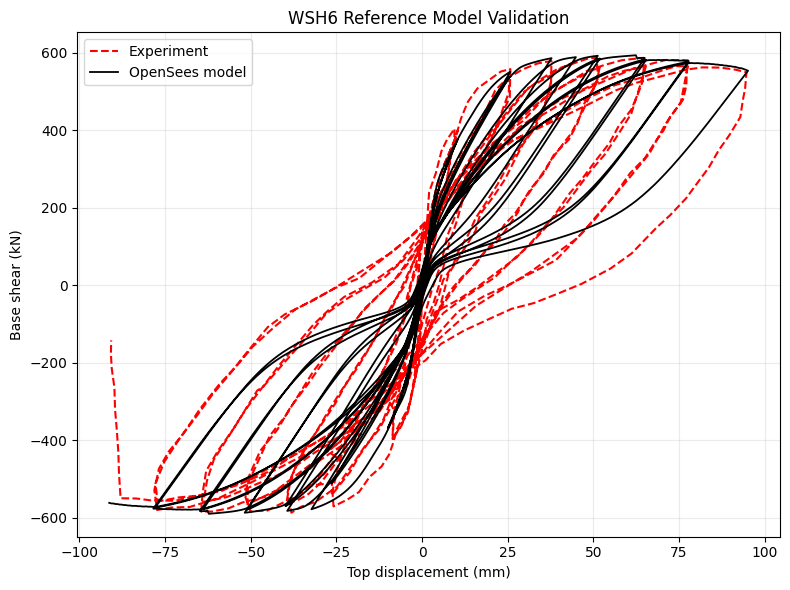

In [8]:
# =============================================================================
# WSH6 REFERENCE MODEL VALIDATION
# =============================================================================

if reference_dir.exists():
    shutil.rmtree(reference_dir)

reference_dir.mkdir(parents=True, exist_ok=True)

base = web_params.loc["Base model"]


# -----------------------------------------------------------------------------
# Run WSH6 reference model
# -----------------------------------------------------------------------------

print("Running WSH6 reference model...")

reference_result = run_wall_model(
    case_id="WSH6_reference",
    fc_MPa=ref.reference_fc_mpa,
    ALR=ref.reference_alr_percent,
    rho_bl=float(base["rho_bl"]),
    rho_sh=float(base["rho_sh"]),
    rho_t=float(base["rho_t"]),
    dbar=float(base["dbar_mm"]),
    webspacing=float(base["webspacing_mm"]),
    calibration_dir=str(calibration_dir) + "/",
    output_root=str(reference_dir),
    disps=disps,
)

try:
    op.remove("recorders")
except Exception:
    pass


# -----------------------------------------------------------------------------
# Read numerical response
# -----------------------------------------------------------------------------

case_dir = reference_dir / "WSH6_reference"

model_disp = np.loadtxt(
    case_dir / "TopDisp.out"
).reshape(-1) * 1000.0

model_force = np.atleast_2d(
    np.loadtxt(case_dir / "RBase.out")
)

model_force = -model_force[:, 1] / 1000.0


# -----------------------------------------------------------------------------
# Read experimental response
# -----------------------------------------------------------------------------

measured = pd.read_csv(measured_file)

test_disp = measured["Displacement (mm)"].to_numpy()
test_force = measured["Force (kN)"].to_numpy()


# -----------------------------------------------------------------------------
# Print comparison
# -----------------------------------------------------------------------------

print()
print("WSH6 reference-model validation")
print("-------------------------------")
print(f"rho_l       = {reference_result['rho_l_computed']:.3f} %")
print()
print(f"model V+    = {model_force.max():.1f} kN")
print(f"test V+     = {test_force.max():.1f} kN")
print(f"V+ ratio    = {model_force.max() / test_force.max():.3f}")
print()
print(f"model V-    = {model_force.min():.1f} kN")
print(f"test V-     = {test_force.min():.1f} kN")
print(
    f"V- ratio    = "
    f"{abs(model_force.min()) / abs(test_force.min()):.3f}"
)


# -----------------------------------------------------------------------------
# Plot numerical and experimental hysteresis
# -----------------------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(test_disp, test_force, "r--", linewidth=1.5, label="Experiment")
plt.plot(model_disp, model_force, "k-", linewidth=1.3, label="OpenSees model")

plt.xlabel("Top displacement (mm)")
plt.ylabel("Base shear (kN)")
plt.title("WSH6 Reference Model Validation")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# 4. Generate the common 20-point LHS and the 620-case design
# =============================================================================


def make_lhs(n, seed, fc_range, alr_range):
    """Generate the common two-dimensional stratified Latin hypercube sample."""
    rng = np.random.default_rng(seed)

    fc_unit = (np.arange(n) + rng.random(n)) / n
    alr_unit = (np.arange(n) + rng.random(n)) / n

    rng.shuffle(fc_unit)
    rng.shuffle(alr_unit)

    fc = fc_range[0] + fc_unit * (fc_range[1] - fc_range[0])
    alr = alr_range[0] + alr_unit * (alr_range[1] - alr_range[0])

    return pd.DataFrame({
        "LHS_sample": np.arange(1, n + 1),
        "LHS_seed": seed,
        "fc_MPa": fc,
        "ALR": alr,
    })


common_lhs = make_lhs(
    n_lhs,
    lhs_seed,
    fc_range_mpa,
    alr_range_percent,
)

rows = []

for _, config in configurations.iterrows():
    name = config["Configuration"]
    is_web = name in web_names

    for _, sample in common_lhs.iterrows():
        lhs_number = int(sample["LHS_sample"])
        case_id = f"{name}_LHS{lhs_number:02d}"

        rows.append({
            "Case_ID": case_id,
            "Configuration": name,
            "Configuration_family": config["Configuration_family"],
            "Reference_specimen": "WSH6",
            "Configuration_source": config_file.name,
            "FE_model_file": (
                "run_FEmodel_webconf.py"
                if is_web
                else "run_FEmodel_boundconf.py"
            ),
            "Sampling_design": "Common crossed 20-point 2D LHS",
            "LHS_n": n_lhs,
            "LHS_sample": lhs_number,
            "LHS_seed": lhs_seed,
            "fc_MPa": float(sample["fc_MPa"]),
            "ALR": float(sample["ALR"]),
            "rho_bl": config["rho_bl"],
            "rho_sh": config["rho_sh"],
            "rho_l": config["rho_l"],
            "rho_t": config["rho_t"],
            "dbar_mm": config["dbar_mm"],
            "webspacing_mm": config["webspacing_mm"],
            "dbar1_mm": config["dbar1_mm"],
            "no_bars_bl": config["no_bars_bl"],
        })

final_design = pd.DataFrame(rows)
expected_runs = len(all_names) * n_lhs

if len(final_design) != 620 or expected_runs != 620:
    raise ValueError(
        f"Expected 620 cases, but {len(final_design)} were generated."
    )

if final_design["Case_ID"].duplicated().any():
    raise ValueError("Duplicate Case_ID values were generated.")

if not (final_design.groupby("Configuration").size() == n_lhs).all():
    raise ValueError("Each configuration must contain exactly 20 LHS cases.")

# Confirm that all configurations use exactly the same 20 fc-ALR pairs.
reference_pairs = final_design.loc[
    final_design["Configuration"].eq(all_names[0]),
    ["LHS_sample", "fc_MPa", "ALR"],
].reset_index(drop=True)

for name in all_names[1:]:
    pairs = final_design.loc[
        final_design["Configuration"].eq(name),
        ["LHS_sample", "fc_MPa", "ALR"],
    ].reset_index(drop=True)

    if not reference_pairs.equals(pairs):
        raise ValueError(f"Common LHS check failed for {name}.")

with pd.ExcelWriter(design_file) as writer:
    final_design.to_excel(writer, sheet_name="All_620_Runs", index=False)
    common_lhs.to_excel(writer, sheet_name="Common_LHS_20", index=False)
    configurations.to_excel(
        writer, sheet_name="Configuration_Definitions", index=False
    )

print(f"Configurations : {len(all_names)}")
print(f"LHS points     : {n_lhs}")
print(f"Total FE runs  : {len(final_design)}")
print(f"Design file    : {design_file}")

display(common_lhs)


Configurations : 31
LHS points     : 20
Total FE runs  : 620
Design file    : /Users/zeynepdeger/Dropbox/ITU Papers/UNDER REVIEW/Analytical Database/Version 1/Jupyter Codes_REV/GITHUB files/opensees_model_GitHub_ready/outputs/WSH6_Final_620_Design.xlsx


,LHS_sample,LHS_seed,fc_MPa,ALR
0,1,120,22.114140,28.832066
1,2,120,39.289373,11.435997
2,3,120,50.720967,41.572102
3,4,120,40.065365,25.230644
4,5,120,44.691650,35.278860
5,6,120,33.086500,19.795806
6,7,120,42.943728,31.604416
7,8,120,29.155455,7.339851
8,9,120,59.748609,37.783512
9,10,120,34.746338,23.741461


In [12]:
# =============================================================================
# 5. Run the 620 nonlinear analyses
# =============================================================================


def run_case(row):
    """Run one case with the appropriate FE model."""
    name = row["Configuration"]
    case_id = row["Case_ID"]
    fc_mpa = float(row["fc_MPa"])
    alr = float(row["ALR"])

    if name in web_names:
        p = web_params.loc[name]

        return run_wall_model(
            case_id=case_id,
            fc_MPa=fc_mpa,
            ALR=alr,
            rho_bl=float(p["rho_bl"]),
            rho_sh=float(p["rho_sh"]),
            rho_t=float(p["rho_t"]),
            dbar=float(p["dbar_mm"]),
            webspacing=float(p["webspacing_mm"]),
            calibration_dir=str(calibration_dir)+ "/",
            output_root=str(fe_runs_dir),
            disps=disps,
        )

    p = boundary_params.loc[name]

    return run_wall_model_BC(
        case_id=case_id,
        fc_MPa=fc_mpa,
        ALR=alr,
        rho_bl=float(p["rho_bl"]),
        rho_sh=float(p["rho_sh"]),
        rho_l=float(p["rho_l"]),
        rho_t=float(p["rho_t"]),
        dbar1=float(p["dbar1_mm"]),
        no_bars_bl=int(p["no_bars_bl"]),
        calibration_dir=str(calibration_dir)+"/",
        output_root=str(fe_runs_dir),
        disps=disps,
    )


# Start fresh or resume from checkpoint.
if rebuild_from_scratch:
    if fe_runs_dir.exists():
        shutil.rmtree(fe_runs_dir)
    fe_runs_dir.mkdir(parents=True, exist_ok=True)

    if checkpoint_file.exists():
        checkpoint_file.unlink()

    checkpoint = pd.DataFrame()

elif checkpoint_file.exists():
    checkpoint = pd.read_excel(checkpoint_file)
    checkpoint = checkpoint.drop_duplicates("Case_ID", keep="last")

else:
    fe_runs_dir.mkdir(parents=True, exist_ok=True)
    checkpoint = pd.DataFrame()


if len(checkpoint) and "Run_status" in checkpoint.columns:
    completed = set(
        checkpoint.loc[
            checkpoint["Run_status"].eq("COMPLETE"),
            "Case_ID",
        ].astype(str)
    )
else:
    completed = set()

records = checkpoint.to_dict("records") if len(checkpoint) else []


for run_number, (_, row) in enumerate(final_design.iterrows(), start=1):
    case_id = str(row["Case_ID"])

    if case_id in completed and not rebuild_from_scratch:
        print(f"[{run_number:03d}/620] {case_id} - checkpoint")
        continue

    case_dir = fe_runs_dir / case_id
    if case_dir.exists():
        shutil.rmtree(case_dir)

    record = row.to_dict()

    try:
        # The FE scripts print detailed convergence information. Suppress it here
        # and keep only the one-line progress report below.
        with open(os.devnull, "w") as devnull:
            with redirect_stdout(devnull), redirect_stderr(devnull):
                result = run_case(row)

        try:
            op.remove("recorders")
        except Exception:
            pass

        # A successful case must contain readable recorder files.
        read_response(case_dir)

        record.update(result)
        record["Run_status"] = "COMPLETE"
        record["Error"] = ""

    except Exception as error:
        try:
            op.remove("recorders")
        except Exception:
            pass

        record["Run_status"] = "ERROR"
        record["Error"] = repr(error)

    # Replace any older checkpoint record for the same case.
    records = [item for item in records if item.get("Case_ID") != case_id]
    records.append(record)

    checkpoint = pd.DataFrame(records)
    checkpoint.to_excel(checkpoint_file, index=False)

    print(
        f"[{run_number:03d}/620] {case_id} - {record['Run_status']}",
        flush=True,
    )


checkpoint = pd.DataFrame(records).drop_duplicates("Case_ID", keep="last")
failed = checkpoint[checkpoint["Run_status"].ne("COMPLETE")]

if len(checkpoint) != 620:
    raise RuntimeError(
        f"Checkpoint contains {len(checkpoint)} cases instead of 620."
    )

if not failed.empty:
    display(failed[["Case_ID", "Error"]])
    raise RuntimeError(
        f"{len(failed)} case(s) failed. Inspect the checkpoint before continuing."
    )

print("620/620 analyses completed successfully.")


[001/620] Base model_LHS01 - COMPLETE
[002/620] Base model_LHS02 - COMPLETE
[003/620] Base model_LHS03 - COMPLETE
[004/620] Base model_LHS04 - COMPLETE


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# 6. Post-process responses and export the final analytical database
# =============================================================================


def interpolate_x(x1, y1, x2, y2, target_y):
    if y2 == y1:
        return float(x2)
    return float(x1 + (target_y - y1) * (x2 - x1) / (y2 - y1))


def make_backbone(disp_m, force_kn, sign=1.0):
    """Return one monotonic backbone as positive displacement/force magnitudes."""
    d = sign * np.asarray(disp_m, dtype=float)
    f = sign * np.asarray(force_kn, dtype=float)

    mask = (d >= 0.0) & (f >= 0.0)
    d = d[mask] * 1000.0
    f = f[mask]

    if len(d) == 0:
        return np.array([]), np.array([])

    backbone_d = []
    backbone_f = []
    last_d = -np.inf

    for di, fi in zip(d, f):
        if di > last_d + 1e-9:
            backbone_d.append(float(di))
            backbone_f.append(float(fi))
            last_d = di

    return np.asarray(backbone_d), np.asarray(backbone_f)


def branch_metrics(d, v):
    """Extract Vmax, yield displacement, ultimate displacement, and ductility."""
    if len(d) < 2:
        return {
            "Vmax_kN": np.nan,
            "Delta_at_Vmax_mm": np.nan,
            "Delta_max_mm": np.nan,
            "Delta_y_mm": np.nan,
            "Delta_20loss_mm": np.nan,
            "Delta_u_mm": np.nan,
            "Ultimate_source": "UNAVAILABLE",
            "Reached_20loss": False,
            "mu": np.nan,
        }

    peak_index = int(np.argmax(v))
    vmax = float(v[peak_index])
    delta_at_vmax = float(d[peak_index])
    delta_max = float(np.max(d))

    # Yield displacement = first attainment of 75% Vmax on the ascending branch.
    yield_target = 0.75 * vmax
    yield_index = np.where(v[:peak_index + 1] >= yield_target)[0]

    if len(yield_index):
        k = int(yield_index[0])
        if k == 0:
            delta_y = float(d[k])
        else:
            delta_y = interpolate_x(
                d[k - 1], v[k - 1], d[k], v[k], yield_target
            )
    else:
        delta_y = np.nan

    # Ultimate displacement = first post-peak attainment of 80% Vmax.
    loss_target = 0.80 * vmax
    post_d = d[peak_index:]
    post_v = v[peak_index:]
    loss_index = np.where(post_v <= loss_target)[0]

    if len(loss_index):
        k = int(loss_index[0])
        if k == 0:
            delta_20loss = float(post_d[k])
        else:
            delta_20loss = interpolate_x(
                post_d[k - 1], post_v[k - 1],
                post_d[k], post_v[k],
                loss_target,
            )
        delta_u = delta_20loss
        ultimate_source = "20pct_loss"
        reached_20loss = True
    else:
        delta_20loss = np.nan
        delta_u = delta_max
        ultimate_source = "delta_max_fallback"
        reached_20loss = False

    mu = delta_u / delta_y if np.isfinite(delta_y) and delta_y > 0 else np.nan

    return {
        "Vmax_kN": vmax,
        "Delta_at_Vmax_mm": delta_at_vmax,
        "Delta_max_mm": delta_max,
        "Delta_y_mm": delta_y,
        "Delta_20loss_mm": delta_20loss,
        "Delta_u_mm": delta_u,
        "Ultimate_source": ultimate_source,
        "Reached_20loss": reached_20loss,
        "mu": mu,
    }


checkpoint = pd.read_excel(checkpoint_file)
checkpoint = checkpoint.drop_duplicates("Case_ID", keep="last")

if len(checkpoint) != 620 or not checkpoint["Run_status"].eq("COMPLETE").all():
    raise RuntimeError("The 620 FE analyses must be complete before post-processing.")

metrics = []

for _, row in final_design.iterrows():
    case_id = row["Case_ID"]
    disp, force = read_response(fe_runs_dir / case_id)

    pos_d, pos_v = make_backbone(disp, force, sign=1.0)
    neg_d, neg_v = make_backbone(disp, force, sign=-1.0)

    pos = branch_metrics(pos_d, pos_v)
    neg = branch_metrics(neg_d, neg_v)

    metrics.append({
        "Case_ID": case_id,
        "Vmax_pos_kN": pos["Vmax_kN"],
        "Delta_max_pos_mm": pos["Delta_max_mm"],
        "Delta_at_Vmax_pos_mm": pos["Delta_at_Vmax_mm"],
        "Delta_y_pos_mm": pos["Delta_y_mm"],
        "Delta_20loss_pos_mm": pos["Delta_20loss_mm"],
        "Delta_u_pos_mm": pos["Delta_u_mm"],
        "Ultimate_source_pos": pos["Ultimate_source"],
        "Reached_20loss_pos": pos["Reached_20loss"],
        "mu_pos": pos["mu"],
        "Vmax_neg_kN": neg["Vmax_kN"],
        "Delta_max_neg_mm": neg["Delta_max_mm"],
        "Delta_at_Vmax_neg_mm": neg["Delta_at_Vmax_mm"],
        "Delta_y_neg_mm": neg["Delta_y_mm"],
        "Delta_20loss_neg_mm": neg["Delta_20loss_mm"],
        "Delta_u_neg_mm": neg["Delta_u_mm"],
        "Ultimate_source_neg": neg["Ultimate_source"],
        "Reached_20loss_neg": neg["Reached_20loss"],
        "mu_neg": neg["mu"],
        "Vmax_abs_kN": np.nanmax([pos["Vmax_kN"], neg["Vmax_kN"]]),
        "Delta_u_abs_mm": np.nanmax([pos["Delta_u_mm"], neg["Delta_u_mm"]]),
        "mu_abs": np.nanmax([pos["mu"], neg["mu"]]),
    })

metrics = pd.DataFrame(metrics)
final_db = checkpoint.merge(metrics, on="Case_ID", how="left", validate="one_to_one")


def fema_label(mode):
    mode = str(mode).strip().upper()
    if mode == "FLEXURE":
        return "Flexure-dominated"
    if mode.startswith("SHEAR"):
        return "Shear-susceptible"
    return np.nan


final_db["FEMA_classification"] = final_db["Failure_mode"].map(fema_label)
final_db["Classification_provenance"] = "FEMA P-2208 capacity-ratio criterion"
final_db["Applicability_domain"] = (
    "WSH6-centered parametric family; fixed geometry, shear-span ratio, "
    "fixed-base condition, and cyclic loading protocol"
)
final_db["Calibration_source"] = "PublicUse/MLmodel"


# Remove internal run bookkeeping from the public database.
public_db = final_db.drop(
    columns=["Run_status", "Error"],
    errors="ignore",
).copy()

# Keep the published ordering: configuration order, then LHS sample.
order = {name: i for i, name in enumerate(all_names)}
public_db["_order"] = public_db["Configuration"].map(order)
public_db = (
    public_db
    .sort_values(["_order", "LHS_sample"])
    .drop(columns="_order")
    .reset_index(drop=True)
)

if len(public_db) != 620:
    raise RuntimeError(f"Final database contains {len(public_db)} rows instead of 620.")
if public_db["Case_ID"].duplicated().any():
    raise RuntimeError("Duplicate Case_ID values were found in the final database.")
if not (public_db.groupby("Configuration").size() == 20).all():
    raise RuntimeError("Each configuration must contain exactly 20 cases.")

metadata = pd.DataFrame({
    "Item": [
        "Reference specimen",
        "Reference source",
        "Reference properties",
        "Configuration source",
        "Web FE model",
        "Boundary FE model",
        "Calibration source",
        "Number of configurations",
        "LHS samples per configuration",
        "Total analytical cases",
        "LHS seed",
        "Concrete strength range (MPa)",
        "ALR range (%)",
        "Web rho_l definition",
    ],
    "Value": [
        "WSH6",
        ref.source_citation,
        "wsh6_reference.py",
        config_file.name,
        "run_FEmodel_webconf.py",
        "run_FEmodel_boundconf.py",
        "PublicUse/MLmodel",
        len(all_names),
        n_lhs,
        len(public_db),
        lhs_seed,
        f"{fc_range_mpa[0]:g}-{fc_range_mpa[1]:g}",
        f"{alr_range_percent[0]:g}-{alr_range_percent[1]:g}",
        "rho_l = n_face * A_bar / (s * t_w)",
    ],
})

with pd.ExcelWriter(final_database_file) as writer:
    public_db.to_excel(writer, sheet_name="Master_620", index=False)
    common_lhs.to_excel(writer, sheet_name="Common_LHS_20", index=False)
    configurations.to_excel(
        writer, sheet_name="Configuration_Definitions", index=False
    )
    metadata.to_excel(writer, sheet_name="Metadata", index=False)

print(f"Final database: {final_database_file}")
print(f"Rows          : {len(public_db)}")
print(f"Configurations: {public_db['Configuration'].nunique()}")
print(f"Cases/config  : {n_lhs}")
